(200, 2) (200, 1)


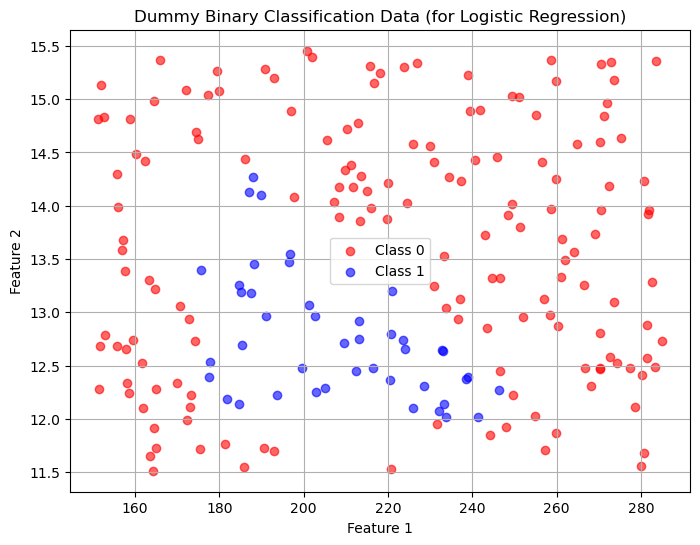

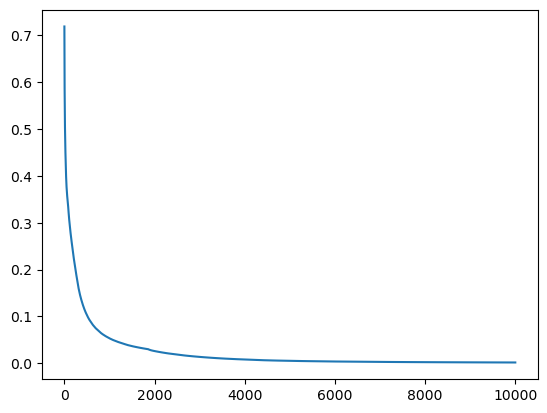

C:\Users\Hp\AppData\Local\Temp\ipykernel_2964\2088219421.py:51: RuntimeWarning: overflow encountered in exp
  return  (1/(1+np.exp(-z)))


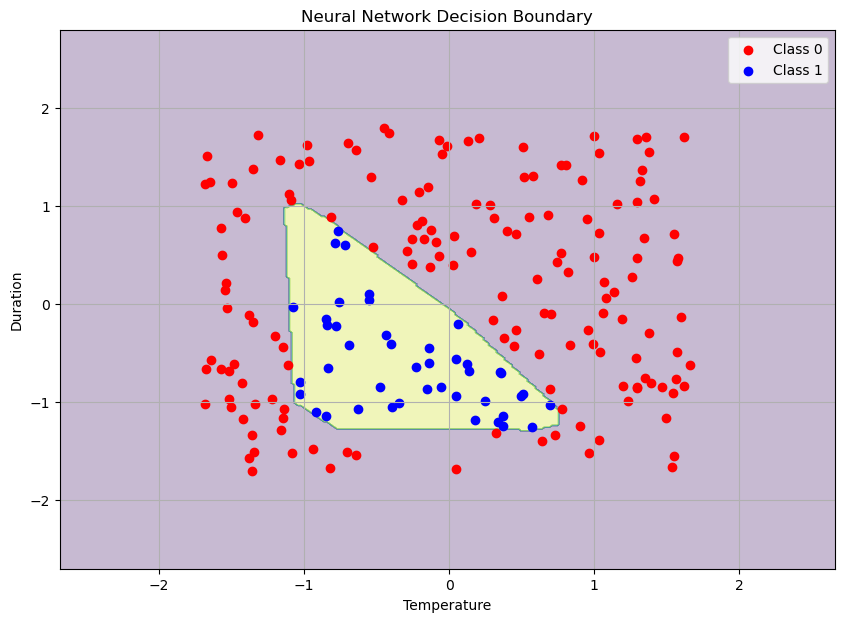

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1,1))

X,y = load_coffee_data()
print(X.shape, y.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

#Normalization
X = (X - X.mean(axis=0)) / X.std(axis=0)

#Neuron-Architecture
neuron_layers=[4,2,3,1]
activations = ["relu","relu","relu","sigmoid"]


w=[]
b=[]
z=[]
m=len(X)
cost_history=[]

#sigmoid function
def sigmoid(z):
    return  (1/(1+np.exp(-z)))

#relu-function
def Relu(z):
    return np.maximum(0,z)

#sigmoid derivative
def g_derivative(z):
    return sigmoid(z)*(1-sigmoid(z))

#relu-derivative
def r_derivative(z):
     return np.where(z > 0, 1, 0)

#hyper-parameters
w.append(np.random.randn(neuron_layers[0],len(X[0])) * np.sqrt(2/neuron_layers[0]))
b.append(np.zeros((neuron_layers[0],1)))

for i in range(1,len(neuron_layers)):
    ww=np.random.randn(neuron_layers[i],neuron_layers[i-1])  * np.sqrt(2/neuron_layers[i-1])
    bb=np.zeros(((neuron_layers[i],1)))
    b.append(bb)
    w.append(ww)
   
#learning-rate
alpha=0.1

#gradient-descent
for iteration in range(10000):
    A=X.T
    z=[]
    AA=[]
    dldw=[]
    dldb=[] 
    
    for i in range(len(neuron_layers)):
        #print(w[i].shape, A.shape, b[i].shape)    
        zz=np.dot(w[i],A) + b[i]
        #print(zz.shape)
        if activations[i]=="sigmoid":
            A=sigmoid(zz)
        if activations[i]=="relu":
            A=Relu(zz)
        z.append(zz)
        AA.append(A)
           

    #cost
    cost = np.mean(-y*np.log(A.T+1e-10)-(1-y)*np.log(1-A.T+1e-10))
    cost_history.append(cost)
    #print(cost)
    
   
#back-propagation
    for i in range(len(neuron_layers)-1,-1,-1): 
       if i == len(neuron_layers)-1: 
          d=AA[i]-y.T 
       else: 
         if activations[i]=="sigmoid": 
             d=w[i+1].T @ d * g_derivative(z[i]) 
         if activations[i]=="relu": 
             d=w[i+1].T @ d * r_derivative(z[i]) 
             
       if i==0:
          dldw.append((d @ X)/m)
          dldb.append(np.sum(d,axis=1,keepdims=True)/m)
       else:
          dldw.append((d @ AA[i-1].T)/m )
          dldb.append(np.sum(d,axis=1,keepdims=True)/m)
    #print(len(dldb))
    dldw = dldw[::-1]
    dldb = dldb[::-1]

    for i in range(len(w)):
        w[i] = w[i] - alpha * dldw[i]
        b[i] = b[i] - alpha * dldb[i]
plt.plot(cost_history)
plt.show()


# -----------------------------
# DECISION BOUNDARY
# -----------------------------

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Create grid points
grid = np.c_[xx.ravel(), yy.ravel()]

# Forward propagation on grid
A = grid.T

for i in range(len(neuron_layers)):

    zz = w[i] @ A + b[i]

    if activations[i] == "sigmoid":
        A = sigmoid(zz)

    if activations[i] == "relu":
        A = Relu(zz)

# Convert probabilities to classes
predictions = (A > 0.5).astype(int)

# Reshape to mesh shape
Z = predictions.reshape(xx.shape)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10,7))

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Original data points
plt.scatter(
    X[y.flatten()==0][:,0],
    X[y.flatten()==0][:,1],
    color='red',
    label='Class 0'
)

plt.scatter(
    X[y.flatten()==1][:,0],
    X[y.flatten()==1][:,1],
    color='blue',
    label='Class 1'
)

plt.xlabel("Temperature")
plt.ylabel("Duration")
plt.title("Neural Network Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()